# R6.05 - Deep Learning pour l'IA
## TP6 - Transformer et Transfer Learning



### 1. Introduction :

L'**apprentissage par transfert** (transfer learning), c’est-à-dire la résolution de tâches à l'aide de modèles pré-entraînés sur de très grandes quantités de données, a changé la donne dans de nombreuses applications d'apprentissage profond. En TAL (Traitement Automatique des Langues), alors que les données annotées sont rares, le texte brut est virtuellement illimité et facilement accessible. Ainsi, la capacité d'apprendre de bonnes représentations à partir de texte simple pourrait grandement améliorer la compréhension générale du langage naturel. L'apprentissage sans étiquettes est rendu possible via l'apprentissage auto-supervisé (self-supervised learning), un cadre dans lequel un système apprend à prédire une partie de son entrée à partir d'autres parties de celle-ci.

Une façon de réaliser ce pré-entraînement est d'utiliser le pré-entraînement génératif d'un modèle de langue. Dans cette phase de pré-entraînement, le modèle apprendra à prédire les prochains jetons (tokens) d'une séquence à partir des précédents.

Cette phase ne nécessite donc aucun type d'annotation en dehors du texte d'entrée lui-même. Une fois que le modèle de langue est suffisamment pré-entraîné, il peut être affiné (fine-tuned) sur des tâches supervisées tout en ne nécessitant que des modifications minimales de son architecture (remplacement de la tête de classification).

Dans ce TP, nous allons :

Implémenter et pré-entraîner un modèle de langue basé sur l'architecture Transformer.

Utiliser le modèle pré-entraîné (transfer learning) pour effectuer une tâche d'analyse de sentiment, qui consiste à classer des critiques de livres en catégories positives et négatives.

Comparer les performances du modèle pré-entraîné à celles d'un modèle entraîné à partir de zéro (from scratch).

### 2. Le Modèle :

Notre modèle est basé sur les **Transformers**. Bien que le Transformer soit un modèle qui suit une structure encodeur-décodeur, il est possible d'utiliser uniquement la partie encodeur (comme dans BERT) ou la partie décodeur (comme dans GPT) pour effectuer certaines tâches spécifiques. Dans ce notebook, nous utilisons un décodeur Transformer multi-couches pour le modèle de langue. Heureusement, les récentes versions de PyTorch incluent des blocs Transformer standards qui peuvent être facilement utilisés et adaptés.

Commençons par implémenter le modèle. Les différentes couches utilisées dans ce modèle sont les suivantes :

- La couche d'embeddings (Embedding layer)
- Le codage positionnel (Positional Embedding)
- Les couches Transformer
- Une couche linéaire pour le décodage et la classification

Le même modèle peut être utilisé pour la modélisation du langage et pour la classification en remplaçant simplement la dernière couche du modèle. C'est pourquoi nous divisons notre modèle en deux modules :

Module de base (base module) : qui se compose des 3 premières couches.

Module de classification (classifier module) : qui se compose de la dernière couche.

Après le pré-entraînement, les paramètres du modèle de base peuvent être "transférés" au modèle utilisé pour la tâche de classification, tandis que le module de classification doit être remplacé par une nouvelle tête initialisée aléatoirement.

Une partie du code est adaptée de cet excellent tutoriel : https://pytorch.org/tutorials/beginner/transformer_tutorial.html


In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

> **T.1**: Remplir les trous dans `TransformerModel()` pour implémenter le modèle.

### The Model

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, nhid, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, nhid)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, nhid, 2).float() * (-math.log(10000.0) / nhid)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0), :]
        return self.dropout(x)

In [3]:
class TransformerModel(nn.Module):
    def __init__(self, ntoken, nhead, nhid, nlayers, dropout=0.5):
        super(TransformerModel, self).__init__()
        '''
        ntokens: the size of vocabulary
        nhid: the hidden dimension of the model.
        We assume that embedding_dim = nhid
        nlayers: the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
        nhead: the number of heads in the multiheadattention models
        dropout: the dropout value
         '''
        self.model_type = "Transformer"
        self.encoder = nn.Embedding(ntoken, nhid) # fill me, nhid = the dim_embed
        self.pos_encoder = PositionalEncoding(nhid, dropout) #fill me, the PositionalEncoding class is implemented in the next cell
        encoder_layers = nn.TransformerEncoderLayer(nhid, nhead, nhid, dropout) #fill me we assume nhid = d_model = dim_feedforward
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, nlayers) #fill me
        self.nhid = nhid
        self.init_weights()

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = (
            mask.float()
            .masked_fill(mask == 0, float("-inf"))
            .masked_fill(mask == 1, float(0.0))
        )
        return mask

    def init_weights(self):
        initrange = 0.1
        self.encoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src, src_mask):
        src = self.encoder(src) * math.sqrt(self.nhid)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, src_mask) #fill me
        return output


class ClassificationHead(nn.Module):
    def __init__(self, nhid, nclasses):
        super(ClassificationHead, self).__init__()
        self.decoder = nn.Linear(nhid, nclasses)
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src):
        output = self.decoder(src) #fill me
        return output

class Model(nn.Module):
    def __init__(self, ntoken, nhead, nhid, nlayers, nclasses, dropout=0.5):
        super(Model, self).__init__()
        self.base = TransformerModel(ntoken, nhead, nhid, nlayers, dropout)
        self.classifier = ClassificationHead(nhid, nclasses)

    def forward(self, src, src_mask):
        # base model
        x = self.base(src, src_mask) #fill me
        # classifier model
        output = self.classifier(x) # fill me
        return output

Nous allons vérifier si le modèle fonctionne, avec une étape d'inférence:

In [4]:
ntokens = 100 #fill me # the size of vocabulary
nhid = 200  # hidden dimension
nlayers = 4  # the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 2  # the number of heads in the multiheadattention models
dropout = 0  # the dropout value

model = Model(ntokens, nhead, nhid, nlayers, ntokens, dropout).to(device)
dummy_input = torch.tensor([[2, 6, 2, 5, 43, 21]]).to(device)
src_mask = model.base.generate_square_subsequent_mask(1).to(device)
out = model.forward(dummy_input, src_mask)

print(out.shape) # is it the right shape?

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


torch.Size([1, 6, 100])


### 3. Vocabulaire et Tokenisation
Pour entraîner le modèle de langue, le texte de notre corpus doit d'abord être tokenisé. Nous utilisons sentencepiece <a href="https://github.com/google/sentencepiece">https://github.com/google/sentencepiece</a> qui implémente le "byte-pair-encoding" (BPE), un algorithme de tokenisation par sous-mots.

Utiliser des sous-mots a deux avantages:

1. réduire la taille du vocabulaire
2. nous pouvons traiter des mots inconnus

Le vocabulaire est fourni dans le fichier `dict.txt`. Chargeons-le et associons chaque jeton (token) à un indice unique.


Dans nos expériences, nous utilisons des jeux de données qui sont déjà tokenisés.

> **T.2** : Complétez les lacunes pour créer les dictionnaires de correspondance token2ind et ind2token.

In [5]:
!wget -nc https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/dict.txt
!head -5 dict.txt

zsh:1: command not found: wget
head: dict.txt: No such file or directory


In [6]:
path_vocab = "dict.txt"
token2ind = {"<sos>": 0, "<pad>": 1, "<eos>": 2, "<oov>": 3} # the 4 first indices are reserved to special tokens
with open(path_vocab, "r") as f:
    for idx, line in enumerate(f):
        word = line.split()[0].strip()
        token2ind[word] = idx + 4  #fill me

ind2token = {value: key for key, value in token2ind.items()} #fill me

print(ind2token[1111])

FileNotFoundError: [Errno 2] No such file or directory: 'dict.txt'

## 4. Chargeur de données (Data Loader)

Nous utilisons la classe `DataLoader` pour charger notre jeu de données et générer les mini-batchs utilisés lors de l'entraînement. La fonction `get_loader()` renvoie un objet `DataLoader`, qui est un itérable sur les échantillons de données. Le chargeur de données peut retourner des mini-batchs pour la modélisation du langage ou pour la classification de séquences, selon l'argument task que nous passons à la fonction `get_loader()`.

Pour la tâche de *language_modeling*, l'entrée et la cible (target) sont toutes deux des batchs de séquences. En réalité, la cible est essentiellement une version décalée de l'entrée, de telle sorte que chaque jeton est prédit en fonction de tous les jetons précédents. Par exemple, pour une séquence A B C D :

**Entrée :** \<sos\>A B C D

**Sortie :** A B C D\<eos\>


Pour la tâche de classification, l'entrée est un batch de séquences et la cible est un batch de labels scalaires (ID du token).


Pour plus d'informations sur les chargeurs de données, consultez : <a href="https://pytorch.org/docs/stable/data.html">https://pytorch.org/docs/stable/data.html</a>


In [7]:
class Dataset(Dataset):
    def __init__(
        self,
        path_documents,
        path_labels=None,
        token2ind={},
        max_len=512,
        task="language_modeling",
    ):
        self.task = task
        self.max_len = max_len
        self.token2ind = token2ind
        self.documents = []
        self.labels = []
        with open(path_documents, "r") as f1:
            for line in f1:
                self.documents.append(line.strip())
        if task == "classification":
            with open(path_labels, "r") as f1:
                for line in f1:
                    self.labels.append(int(line.strip()))
            assert len(self.labels) == len(self.documents)

    def __len__(self):
        return len(self.documents)

    def __getitem__(self, index):
        sequence = self.documents[index].split()
        if len(sequence) > self.max_len - 1:
            sequence = sequence[: self.max_len - 1]
        source_sequence = [self.token2ind["<sos>"]] + [
            self.token2ind[word] if word in self.token2ind else self.token2ind["<oov>"]
            for word in sequence[: self.max_len]
        ]
        if self.task == "language_modeling":
            target = source_sequence[1:]
            target.append(self.token2ind["<eos>"])
        elif self.task == "classification":
            target = [self.labels[index]]
        sample = {
            "source_sequence": torch.tensor(source_sequence),
            "target": torch.tensor(target),
        }
        return sample


def MyCollator(batch):
    source_sequences = pad_sequence(
        #we use padding to match the length of the sequences in the same batch
        [sample["source_sequence"] for sample in batch], padding_value=token2ind["<pad>"]
    )
    target = pad_sequence(
        [sample["target"] for sample in batch], padding_value=token2ind["<pad>"]
    )
    return source_sequences, target.reshape(-1)


def get_loader(
    path_documents,
    path_labels=None,
    token2ind={},
    max_len=512,
    batch_size=32,
    task="language_modeling",
):
    dataset = Dataset(
        path_documents,
        path_labels=path_labels,
        token2ind=token2ind,
        max_len=512,
        task=task,
    )
    data_loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=MyCollator,
        pin_memory=False,
        drop_last=True,
    )
    return data_loader

In [8]:
ntokens = len(ind2token) #fill me # the size of vocabulary
nhid = 200  # the dimension of the feedforward network model in nn.TransformerEncoder
nlayers = 4  # the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 2  # the number of heads in the multiheadattention models
dropout = 0  # the dropout value

nclasses = 2 # for classification task only

model = Model(ntokens, nhead, nhid, nlayers, ntokens, dropout).to(device)

In [9]:
# optimization parameters
criterion = nn.CrossEntropyLoss(ignore_index=token2ind['<pad>'])
lr = 0.0003  # learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [10]:
!wget -nc https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/pretraining_subset.txt
path_data_train = "pretraining_subset.txt"

Il file «pretraining_subset.txt» è già presente, non viene scaricato.



## 5. Etape entraînement

Dans cette section, nous allons implémenter une fonction `train()` qui entraîne notre modèle pendant une époque. Comme nous l'avons mentionné, nous utiliserons dans ce TP un objectif de modélisation du langage lors de la phase de pré-entraînement. À partir des jetons précédents d'une séquence, le modèle tentera de prédire le suivant.

La même fonction peut être utilisée aussi bien pour la phase de pré-entraînement que pour la phase d'ajustement (fine-tuning).

La procédure d'entraînement est la suivante :

1. Itérer sur le chargeur de données (data-loader).
2. À chaque itération, effectuer une passe avant (forward pass).
3. Calculer la perte (loss) par rétropropagation.
4. Mettre à jour les paramètres de votre modèle en utilisant la SGD (descente de gradient stochastique).
5. Répéter pendant n époques.

<b>N.B :</b> Alors que dans la tâche de language_modeling, tous les vecteurs en sortie du modèle de base sont utilisés, dans la tâche de classification, nous n'utilisons que le vecteur représentant le dernier jeton pour effectuer la prédiction.

> **T.3**: Compléter la fonction `train()` .


In [11]:
def train(
    path_data_train: str,
    path_labels_train=None,
    log_interval=5,
    task="language_modeling",
    batch_size=32,
    max_step: int = None,
    current_epoch = None,
):
    model.train()
    total_loss = 0.0
    ntokens = len(token2ind)
    data_loader = get_loader(
        path_data_train,
        path_labels_train,
        token2ind,
        task=task,
        batch_size=batch_size,
    )

    losses = []
    for idx, data in enumerate(data_loader): #1
        optimizer.zero_grad()
        src_mask = model.base.generate_square_subsequent_mask(data[0].size(0)).to(
            device
        )
        input = data[0].to(device)
        output = model(input, src_mask) #2
        if task == 'classification':
            output = output[-1, :]
        output = output.view(-1, output.shape[-1])
        target = data[1] #fill me
        target = target.to(device)
        loss = criterion(output, target) #fill me, Cross entropy check next cells
        loss.backward() #3
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5) # prevent exploding gradient
        optimizer.step() #4
        total_loss += loss.item() # fill me
        if (idx % log_interval == 0 and idx > 0) or (max_step is not None and idx == max_step):
            cur_loss = total_loss / log_interval
            print(
                "| epoch {:3d} | {:5d}/{:5d} steps | "
                "loss {:5.5f} | ppl {:8.3f}".format(
                    current_epoch, idx, len(data_loader), cur_loss, math.exp(cur_loss),
                )
            )
            losses.append(cur_loss)
            total_loss = 0

        if max_step is not None and idx >= max_step:
            break

    return losses

In [12]:
#pretraining on a tiny subset
log_interval = 50
epochs = 1
for epoch in range(1, epochs + 1): #5
    train(
        path_data_train,
        task="language_modeling",
        batch_size=16,
        log_interval=log_interval,
        max_step=500,
        current_epoch=epoch,
    )

| epoch   1 |    50/ 3125 steps | loss 9.43410 | ppl 12507.711
| epoch   1 |   100/ 3125 steps | loss 7.59282 | ppl 1983.895
| epoch   1 |   150/ 3125 steps | loss 7.38069 | ppl 1604.697
| epoch   1 |   200/ 3125 steps | loss 7.21284 | ppl 1356.736
| epoch   1 |   250/ 3125 steps | loss 7.12417 | ppl 1241.621
| epoch   1 |   300/ 3125 steps | loss 6.93053 | ppl 1023.036
| epoch   1 |   350/ 3125 steps | loss 6.84924 | ppl  943.164
| epoch   1 |   400/ 3125 steps | loss 6.94530 | ppl 1038.257
| epoch   1 |   450/ 3125 steps | loss 6.71712 | ppl  826.437
| epoch   1 |   500/ 3125 steps | loss 6.76800 | ppl  869.570


## 6. Etape Génération de texte

Ayant été entraîné sur un objectif de modélisation du langage, notre modèle peut être utilisé en mode **inférence** pour générer ou compléter des phrases. Cependant, la phase de pré-entraînement prend beaucoup de temps par rapport à celle de l'ajustement (fine-tuning).

Bien entendu, nous ne disposons pas d'assez de temps et de ressources pour pré-entraîner efficacement notre modèle ; nous allons donc charger les poids à partir d'un point de sauvegarde (*checkpoint*) qui a été pré-entraîné pendant 12 heures sur un GPU.

Voir ici pour plus d'infos sur les *checkpoints*: <a href="https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-a-general-checkpoint-for-inference-and-or-resuming-training">https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-a-general-checkpoint-for-inference-and-or-resuming-training</a><br>


> **T.4** Implémentez la fonction `infer_next_tokens()` qui prend en entrée une chaîne de caractères sent et un entier `max_len`, et renvoie une complétion de la phrase d'entrée. La génération doit s'arrêter lorsque le modèle génère &lt;eos&gt; ou que la longueur de la phrase générée atteint `max_len`


In [13]:
!wget -nc https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/pretrained_model_4layers.pt

model = Model(ntokens, nhead, nhid, nlayers, ntokens).to(device)

#load the checkpoint
checkpoint = torch.load('pretrained_model_4layers.pt', map_location=device)
#load state dict
model.load_state_dict(checkpoint['model_state_dict'])

Il file «pretrained_model_4layers.pt» è già presente, non viene scaricato.



/usr/local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


<All keys matched successfully>

In [14]:
!wget -nc https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/sentencepiece.french.model

import sentencepiece as spm

s = spm.SentencePieceProcessor(model_file='sentencepiece.french.model') #load sentencepiece model

#examples
encoded = s.encode_as_pieces("Bonjour les amis!")
decoded = s.decode_pieces(encoded)
print(encoded)
print(decoded)

Il file «sentencepiece.french.model» è già presente, non viene scaricato.

['▁Bonjour', '▁les', '▁amis', '!']
Bonjour les amis!


In [15]:
def infer_next_token(sent):
    model.eval()
    sent_pieces = s.encode_as_pieces(sent)
    source = [token2ind['<sos>']] + [token2ind[el] for el in sent_pieces]
    source = torch.tensor(source).to(device)
    source = source.reshape(-1, 1)
    src_mask = model.base.generate_square_subsequent_mask(source.size(0)).to(device)
    out = model(source, src_mask)
    next_token_ind = out[-1].argmax(-1)
    return next_token_ind, out

def infer_next_tokens(sent, max_len=50) -> str:
    sent_pieces = sent.split()
    while True: #greedy
        token_ind, out = infer_next_token(' '.join(sent_pieces)) #fill me
        token = ind2token[token_ind.item()]
        if token == '<eos>': # fill me
            return " ".join(sent_pieces)
        sent_pieces.append(s.decode_pieces([token]))
        if len(sent_pieces) >= max_len:
            return " ".join(sent_pieces)

In [16]:
sent = "Bonjour les"
infer_next_tokens(sent)

'Bonjour les gens qui ont été très accueillants et sympathiques .'

## 7. Mode classification

Il est temps d'entraîner le modèle sur la tâche supervisée, qui est dans notre cas l'analyse de sentiment. Elle consiste à prédire si une critique de livre est positive ou négative. Le modèle sera entraîné selon deux configurations :


<ul> <li><b>Entraînement à partir de zéro</b> (Training from scratch) : Tous les paramètres du modèle sont initialisés de manière aléatoire.</li> <li><b>Apprentissage par transfert</b> (Transfer learning) : Seule la tête de classification est entraînée à partir de zéro, tous les autres paramètres sont copiés du modèle pré-entraîné.</li> </ul>

La fonction d'entraînement est déjà implémentée. Cependant, pour évaluer le modèle à chaque époque, nous devons implémenter une fonction qui calcule la précision (accuracy) du modèle sur l'ensemble de validation.



In [17]:
!wget -nc https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/train.review.spm
!wget -nc https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/train.label
!wget -nc https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/test.review.spm
!wget -nc https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/test.label

path_data_train = "train.review.spm"
path_labels_train = "train.label"

path_data_valid = "test.review.spm"
path_labels_valid = "test.label"

--2026-02-02 14:14:35--  https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/train.review.spm
Risoluzione di raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connessione a raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connesso.
Richiesta HTTP inviata, in attesa di risposta... 200 OK
Lunghezza: 1495960 (1,4M) [text/plain]
Salvataggio in: «train.review.spm»

train.review.spm    100%[===================>]   1,43M  --.-KB/s    in 0,09s   

2026-02-02 14:14:35 (15,5 MB/s) - «train.review.spm» salvato [1495960/1495960]

--2026-02-02 14:14:35--  https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/train.label
Risoluzione di raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connessione a raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... c

> **T.5:** Implementer la fonction <code>accuracy()</code>. La fonction prend en entrée un <code>data_loader</code> et retourne un float (la précision moyenne sur les données du data_loader).<br>

In [20]:
# a function to evaluate the validation accuracy of the model.
def evaluate_accuracy(data_loader):
    model.eval()
    total_loss = 0.0
    ntokens = len(token2ind)
    ncorrect = ntotal = 0
    with torch.no_grad():
        for idx, data in enumerate(data_loader):
            src_mask = model.base.generate_square_subsequent_mask(
                data[0].size(0)
            ).to(device)
            # inference
            output = model(data[0].to(device), src_mask) #fill me
            output = output[-1, :] # only last vector
            # total number of examples
            ntotal += output.shape[0] #fill me
            # number of correct predictions
            predictions = torch.argmax(output, -1)
            ncorrect += torch.sum(predictions == data[1].to(device)) #fill me
        acc = ncorrect.item() / ntotal
        print("validation accuracy: {}".format(acc))
        return acc

In [21]:
#sauvegardons le modèle pre-entrainé pour tester après
torch.save({"model_state_dict": model.base.state_dict(),}, "pretrained_model_4layers_no_class_head.pt")

Nous allons maintenant entraîner le modèle à partir de zéro d'abord, après nous allons aussi faire le fine-tuning du modèle pre-entraîné:

In [22]:
from_scratch_settings = [True, False]

from_scratch_valid_acc = []
pretrained_valid_acc = []
lr = 0.0001

for from_scratch in from_scratch_settings:
    model = Model(ntokens, nhead, nhid, nlayers, 2, dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if not from_scratch:
        print("=====PRETRAINED MODEL======")
        #load checkpoint
        checkpoint = torch.load("pretrained_model_4layers_no_class_head.pt")
        #load state dict
        model.base.load_state_dict(checkpoint['model_state_dict'])
    else:
        print("=====Trainig FROM SCRATCH======")
    epochs = 10
    for epoch in range(1, epochs + 1):
        train(
            path_data_train,
            path_labels_train,
            task='classification',
            batch_size=8,
            log_interval=50,
            current_epoch=epoch,
        )
        acc = evaluate_accuracy(
            get_loader(
                path_data_valid,
                path_labels_valid,
                token2ind=token2ind,
                batch_size=20,
                task='classification',
            )
        )
        if from_scratch:
            from_scratch_valid_acc.append(acc)
        else:
            pretrained_valid_acc.append(acc)
    print()

=====Trainig FROM SCRATCH======
| epoch   1 |    50/  200 steps | loss 0.80272 | ppl    2.232
| epoch   1 |   100/  200 steps | loss 0.70834 | ppl    2.031
| epoch   1 |   150/  200 steps | loss 0.70644 | ppl    2.027
validation accuracy: 0.54
| epoch   2 |    50/  200 steps | loss 0.67389 | ppl    1.962
| epoch   2 |   100/  200 steps | loss 0.64390 | ppl    1.904
| epoch   2 |   150/  200 steps | loss 0.56520 | ppl    1.760
validation accuracy: 0.7055
| epoch   3 |    50/  200 steps | loss 0.32412 | ppl    1.383
| epoch   3 |   100/  200 steps | loss 0.33982 | ppl    1.405
| epoch   3 |   150/  200 steps | loss 0.42479 | ppl    1.529
validation accuracy: 0.7185
| epoch   4 |    50/  200 steps | loss 0.15338 | ppl    1.166
| epoch   4 |   100/  200 steps | loss 0.09992 | ppl    1.105
| epoch   4 |   150/  200 steps | loss 0.13476 | ppl    1.144
validation accuracy: 0.706
| epoch   5 |    50/  200 steps | loss 0.00890 | ppl    1.009
| epoch   5 |   100/  200 steps | loss 0.02965 | ppl 

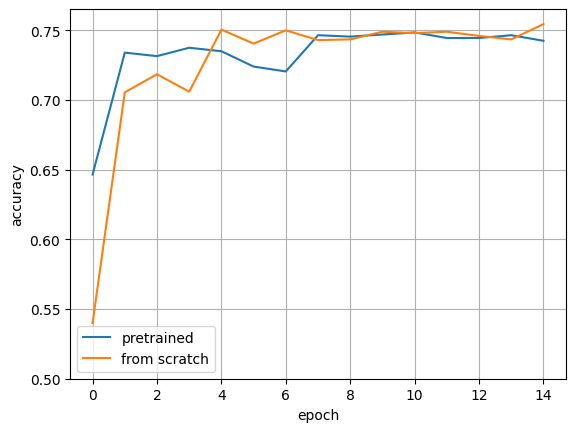

In [23]:
plt.grid()
plt.plot(pretrained_valid_acc, label='pretrained') #fill me
plt.plot(from_scratch_valid_acc, label='from scratch') #fill me
plt.ylim(.5)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

> **Q.1** étudiez le graphique ci-dessus: qu'est-ce qu'on peut déduire de la comparaison entre les deux modalités d'entraînement?

A.1: le fine-tuning du modèle pre-entraîné permet d'obtenir des meilleurs résultats, spécialement avec moins d'époques d'entraînement: les connaissances acquises par le modèle sur les textes en général, avec la modalité de prediction de texte, sont utiles aussi pour une tâche qui n'est pas la prédiction de texte! Cela est un résultat très important qui est aussi à la base du fonctionnement des LLMs qu'on utilise aujourd'hui